# Полиномы Чебышева

- [Реккурентная формула](#построение-полинома-чебышева)
- [Приближение функции по сетке Чебышева](#приближение-функции-по-сетке-чебышева)

### Построение полинома Чебышева

$T_0(x) = 1, \quad T_1(x) = x$

$T_m(x) = 2x \cdot T_{m-1}(x) - T_{m-2}(x)$

_Теорема о тригонометрическом виде полинома Чебышева:_ 

$$T_m(x) = \text{cos}(m \cdot \text{arccos }x), \qquad x \in [-1, 1]$$

_Корни при $x \in [-1, 1]$:_ 
$$ x_k = \text{cos}\Big(\frac{\pi + 2\pi k}{2m}\Big), \quad k = 0, 1, .., m-1$$

_Проекция корней на отрезок $[a, b]$:_

$$ x_k = \frac{1}{2}(a + b) + \frac{1}{2}(b-a) \text{cos}\Big( \frac{ \pi + 2\pi k}{2m} \Big), \qquad k = 0,1, .., m-1$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numdifftools as nd
import math

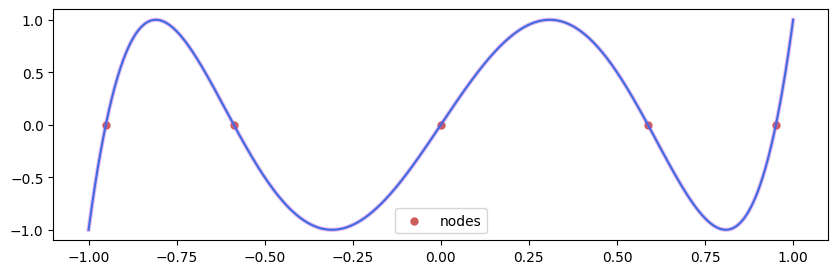

In [3]:
def T(m, x):
    T_0, T_1 = np.ones(len(x)), x
    for _ in range(m):
        T_1, T_0 = 2*x * T_1 - T_0, T_1 
    return T_0

def T_trig(m, x):
    return np.cos(m * np.arccos(x))

m = 5
xx = np.linspace(-1, 1, 1000)

nodes = [np.cos( (np.pi + 2*np.pi*k) / (2*m)) for k in range(m)]

plt.figure(figsize=(10, 3))
plt.scatter(nodes, T_trig(m, nodes), color='indianred', s=25, label='nodes')
plt.plot(xx, T_trig(m, xx), color='mediumorchid', linewidth=3, alpha=0.4)
plt.plot(xx, T_trig(m, xx), color='royalblue', linewidth=1.5)

plt.legend()
plt.show()

### Приближение функции по сетке Чебышева

Рассмотрим функцию Рунге:

$$f(x) = \frac{1}{1+25x^2}, \qquad x \in [a, b]$$

Приблизим ее интерполяционным полиномом $Q_m(x)$ старшей степени $m$ по сетке из корней полинома Чебышева
- Заметим, что для построения полинома степени $m$ нужно рассматривать полином Чебышева степени $(m+1)$

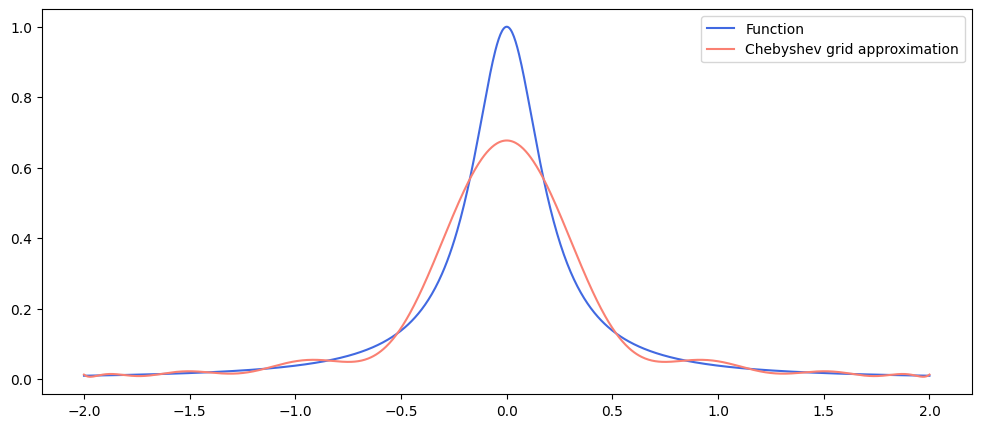

In [13]:
def f(x):
    #return np.heaviside(x + 1,1)*np.heaviside(1 - x,1)
    return 1/(1 + 25*x**2)

def Q(x,y,t):
    n = len(x)
    Q_n = 0
    omega = 1
    for i in range(n):
        L = 1
        for j in range(n):
            if j != i:
                L *= (t - x[j])/(x[i] - x[j])
        Q_n += L*y[i]
        omega *= (t - x[i])
    return Q_n, omega


a, b = -2, 2
t = np.linspace(a, b, 1000) # точки на отрезке [a, b]

m = 17
# узлы для интерполяционного полинома старшей степени m
xx = np.linspace(a, b, m + 1)
yy = f(xx)

# проекция корней полинома Чебышева на отрезок [a, b]
xx_T = np.array([(a+b)/2 + (b-a)/2*np.cos((np.pi + 2*np.pi*i)/(2*(m + 1))) for i in range(m + 1)])
yy_T = f(xx_T)

Q_U, omega_U = Q(xx, yy, t)
Q_T, omega_T = Q(xx_T, yy_T, t)

plt.figure(figsize=(12, 5))
plt.plot(t , f(t), color = 'royalblue', label = 'Function')
#plt.plot(t ,Q_U, color = 'plum', label = 'Approximation')
plt.plot(t ,Q_T, color = 'salmon', label = 'Chebyshev grid approximation')
plt.legend()
plt.show()

_Обозначение:_ $\quad \overline{P}_m(x) = x^m + a_{m-1}x^{m-1} + ... + a_0, \quad (a_m = 1)$ 

_Теорема:_ $\quad \overline{T}_m(x) = 2^{1-m} \cdot T_{m}(x)\: $ _(коэффициент перед $x^m$ равен 1)_

$$\underset{x \in [-1, 1]}{\text{max }}\big| \overline{P}_m(x) \big| \geqslant \underset{x \in [-1, 1]}{\text{max }}\big| \overline{T}_m(x) \big| = 2^{1-m}$$

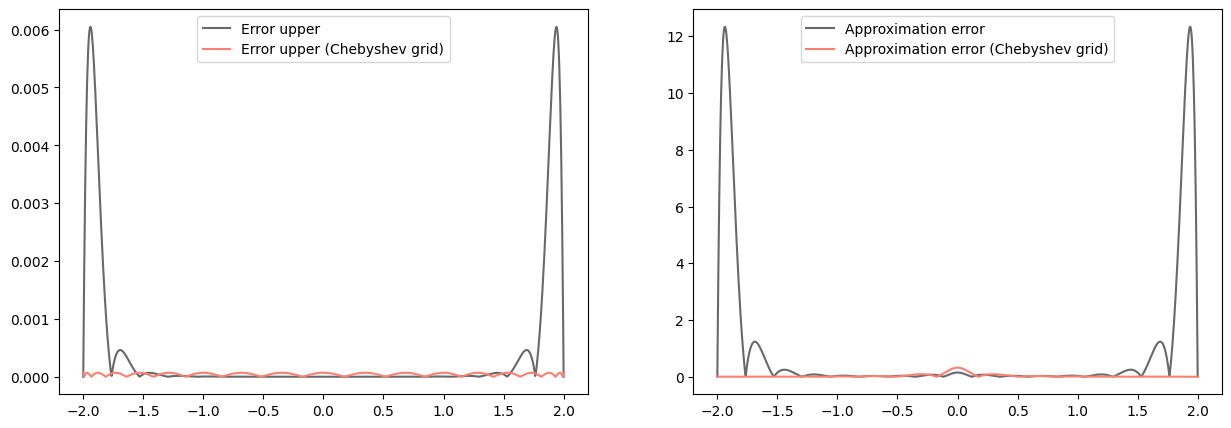

In [16]:
dfdx_m = nd.Derivative(f, n = m + 1)(t)
M = np.abs(dfdx_m[np.argmax(np.abs(dfdx_m))])

err_upper = M / math.factorial(m+1)*np.abs(omega_U)
err_upper_T = M / math.factorial(m+1)*np.abs(omega_T)

err_fact = np.abs(f(t) - Q_U)
err_fact_T = np.abs(f(t) - Q_T)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axs[0].plot(t, err_upper, color = 'dimgrey', label = 'Error upper')
axs[0].plot(t, err_upper_T, color = 'salmon', label = 'Error upper (Chebyshev grid)')
axs[0].legend()

axs[1].plot(t, err_fact, color = 'dimgrey', label = 'Approximation error')
axs[1].plot(t, err_fact_T, color = 'salmon', label = 'Approximation error (Chebyshev grid)')
axs[1].legend()

plt.show()